# Temporal Session: Long Stream With Recall and FDR

Goal: run `TemporalSession` on a larger synthetic time-series and monitor cumulative `recall` and `FDR` over stream steps.

## Import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import false_discovery_control
from sklearn.ensemble import IsolationForest

from nonconform import ConformalDetector, Split
from nonconform.martingales import AlarmConfig, PowerMartingale
from nonconform.metrics import false_discovery_rate, statistical_power
from nonconform.temporal import TemporalSession

try:
    from online_fdr.investing.alpha.alpha import Gai
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Install optional dependency: pip install nonconform[fdr]"
    ) from exc

## Setup

In [2]:
rng = np.random.default_rng(42)

x_train = rng.standard_normal((1000, 5))

# Long stream: 4k reference + 2k shifted samples
x_stream_reference = rng.standard_normal((4000, 5))
x_stream_shifted = rng.standard_normal((2000, 5)) + 2.0
x_stream = np.vstack([x_stream_reference, x_stream_shifted])
y_stream = np.concatenate(
    [
        np.zeros(len(x_stream_reference), dtype=int),
        np.ones(len(x_stream_shifted), dtype=int),
    ]
)

batch_size = 50
stream_batches = [
    x_stream[i : i + batch_size] for i in range(0, len(x_stream), batch_size)
]

shift_start_step = (len(x_stream_reference) // batch_size) + 1
n_steps = len(stream_batches)

print(f"train samples: {len(x_train)}")
print(f"stream samples: {len(x_stream)}")
print(f"steps: {n_steps} (batch_size={batch_size})")
print(f"shift starts at step: {shift_start_step}")

train samples: 1000
stream samples: 6000
steps: 120 (batch_size=50)
shift starts at step: 81


## Run Temporal Session

Uses `Gai` from `online_fdr` for sequential multiple testing control.

`statistical_power` is used as recall (TPR) in this binary setup.


In [3]:
detector = ConformalDetector(
    detector=IsolationForest(random_state=42),
    strategy=Split(n_calib=0.2),
    score_polarity="auto",
    seed=42,
)
detector.fit(x_train)

alpha = 0.1
session = TemporalSession(
    detector=detector,
    online_controller=Gai(alpha=alpha, wealth=0.05),
    martingale=PowerMartingale(
        epsilon=0.5,
        alarm_config=AlarmConfig(ville_threshold=20.0),
    ),
)

y_seen: list[int] = []
online_seen: list[int] = []
batch_seen: list[int] = []
p_seen: list[float] = []
rows = []

for step, batch in enumerate(stream_batches, start=1):
    result = session.step(batch, apply_batch_select=True, alpha=alpha)
    online = np.asarray(result.online_decisions, dtype=bool)
    batch_sel = np.asarray(session.last_batch_decisions, dtype=bool)
    p_batch = np.asarray(result.p_values, dtype=float)

    start = (step - 1) * batch_size
    stop = start + len(batch)
    y_batch = y_stream[start:stop]

    y_seen.extend(y_batch.tolist())
    online_seen.extend(online.astype(int).tolist())
    batch_seen.extend(batch_sel.astype(int).tolist())
    p_seen.extend(p_batch.tolist())

    y_cum = np.asarray(y_seen, dtype=int)
    online_cum = np.asarray(online_seen, dtype=int)
    batch_cum = np.asarray(batch_seen, dtype=int)

    global_bh = false_discovery_control(np.asarray(p_seen), method="bh") <= alpha

    rows.append(
        {
            "step": step,
            "samples_seen": int(stop),
            "mean_p": float(np.mean(p_batch)),
            "online_recall": float(statistical_power(y=y_cum, y_hat=online_cum)),
            "batch_recall": float(statistical_power(y=y_cum, y_hat=batch_cum)),
            "global_bh_recall": float(
                statistical_power(y=y_cum, y_hat=np.asarray(global_bh, dtype=int))
            ),
            "online_fdr": float(false_discovery_rate(y=y_cum, y_hat=online_cum)),
            "batch_fdr": float(false_discovery_rate(y=y_cum, y_hat=batch_cum)),
            "global_bh_fdr": float(
                false_discovery_rate(y=y_cum, y_hat=np.asarray(global_bh, dtype=int))
            ),
            "online_cum_discoveries": int(np.sum(online_cum)),
            "batch_cum_discoveries": int(np.sum(batch_cum)),
            "global_bh_cum_discoveries": int(np.sum(global_bh)),
            "alarm": bool(result.triggered_alarms),
        }
    )

summary = pd.DataFrame(rows)
summary.tail(10)

,step,samples_seen,mean_p,online_recall,batch_recall,global_bh_recall,online_fdr,batch_fdr,global_bh_fdr,online_cum_discoveries,batch_cum_discoveries,global_bh_cum_discoveries,alarm
110,111,5550,0.013831,0.0,0.981290,0.916774,0.0,0.0,0.073664,0,1521,1534,True
111,112,5600,0.013532,0.0,0.981250,0.916875,0.0,0.0,0.071519,0,1570,1580,True
112,113,5650,0.009154,0.0,0.981818,0.918182,0.0,0.0,0.069410,0,1620,1628,True
113,114,5700,0.011045,0.0,0.981765,0.928824,0.0,0.0,0.080908,0,1669,1718,True
114,115,5750,0.018209,0.0,0.980571,0.929143,0.0,0.0,0.078754,0,1716,1765,True
115,116,5800,0.011542,0.0,0.981111,0.927778,0.0,0.0,0.076838,0,1766,1809,True
116,117,5850,0.014328,0.0,0.981081,0.927027,0.0,0.0,0.074973,0,1815,1854,True
117,118,5900,0.011045,0.0,0.981053,0.926316,0.0,0.0,0.073196,0,1864,1899,True
118,119,5950,0.015522,0.0,0.980000,0.926154,0.0,0.0,0.071465,0,1911,1945,True
119,120,6000,0.013035,0.0,0.980000,0.925500,0.0,0.0,0.069849,0,1960,1990,True


## Time-Series Metrics

- `online_*`: sequential decisions from `Gai` (`online_fdr`)
- `batch_*`: per-step BH on each mini-batch (side-by-side comparator)
- `global_bh_*`: BH on all p-values seen so far (oracle-style cumulative comparator)


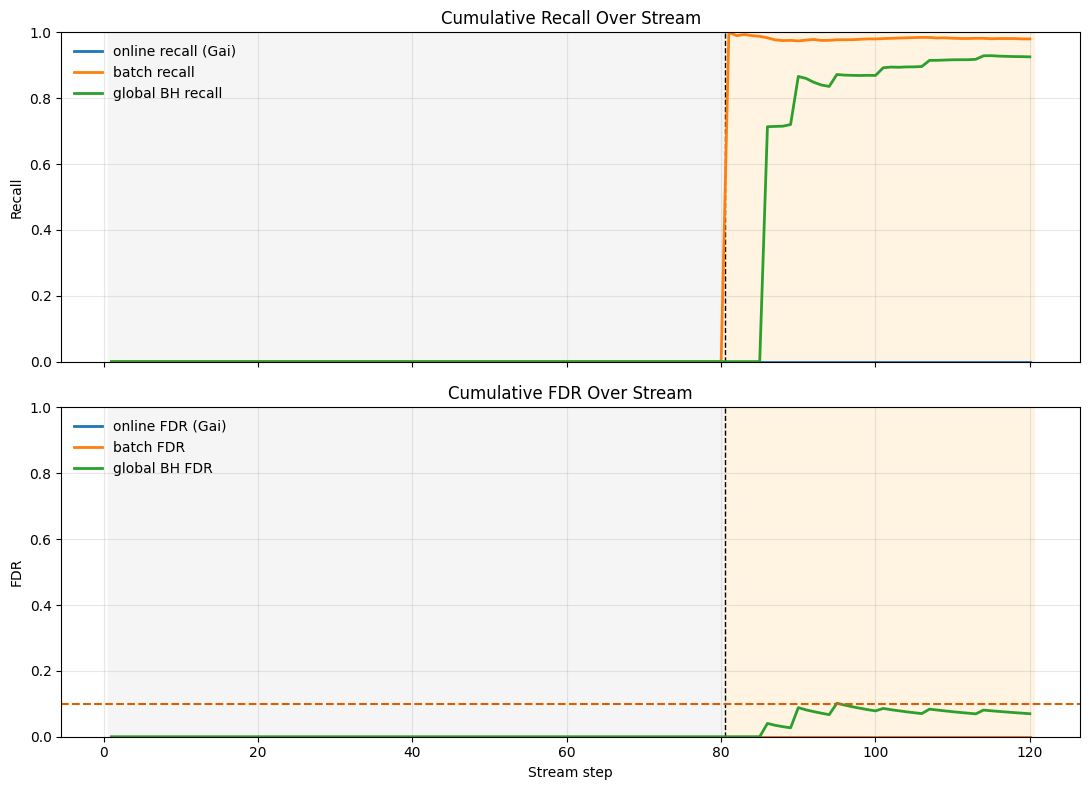

In [4]:
steps = summary["step"]
boundary = shift_start_step - 0.5

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for ax in axes:
    ax.axvspan(0.5, boundary, color="#f4f4f4", alpha=0.9)
    ax.axvspan(boundary, steps.max() + 0.5, color="#fff2df", alpha=0.9)
    ax.axvline(boundary, color="black", linestyle="--", linewidth=1)
    ax.grid(alpha=0.3)

axes[0].plot(
    steps,
    summary["online_recall"],
    linewidth=2,
    label="online recall (Gai)",
)
axes[0].plot(
    steps,
    summary["batch_recall"],
    linewidth=2,
    label="batch recall",
)
axes[0].plot(
    steps,
    summary["global_bh_recall"],
    linewidth=2,
    label="global BH recall",
)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel("Recall")
axes[0].set_title("Cumulative Recall Over Stream")
axes[0].legend(frameon=False, loc="upper left")

axes[1].plot(
    steps,
    summary["online_fdr"],
    linewidth=2,
    label="online FDR (Gai)",
)
axes[1].plot(
    steps,
    summary["batch_fdr"],
    linewidth=2,
    label="batch FDR",
)
axes[1].plot(
    steps,
    summary["global_bh_fdr"],
    linewidth=2,
    label="global BH FDR",
)
axes[1].axhline(alpha, color="#d95f02", linestyle="--", linewidth=1.5)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel("FDR")
axes[1].set_xlabel("Stream step")
axes[1].set_title("Cumulative FDR Over Stream")
axes[1].legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()